In [4]:
import os
import json
import re
from typing import List, TypedDict, Annotated, Sequence, Any

from dotenv import load_dotenv
import requests
import numpy as np
from save_result import append_to_response
from preprocessing import create_chunks, init_chroma, load_docs

from langchain.docstore.document import Document
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain.retrievers import EnsembleRetriever
from langchain_chroma import Chroma
from langchain_community.retrievers import BM25Retriever

from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage, AIMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages



# -------------------------------------------------------------------
# ENVIRONMENT & MODEL INITIALIZATION
# -------------------------------------------------------------------
load_dotenv()
MODEL_NAME       = os.getenv("MODEL_NAME", "qwen/qwen3-32b")
SERPER_API_KEY   = os.getenv("SERPER_API_KEY")
PDF_DIR          = os.getenv("PDF_DIR", "PDFs/")
ALL_DOCS_JSON    = os.getenv("ALL_DOCS_JSON", "all_docs.json")
CHROMA_DB_PATH   = os.getenv("CHROMA_DB_PATH", "chromaDB/saved/")
COLLECTION_NAME  = os.getenv("COLLECTION_NAME", "RAG_DOCS")
EMBED_MODEL_NAME = os.getenv("EMBED_MODEL_NAME", "sentence-transformers/all-MiniLM-L6-v2")
ALPHAVANTAGE_API_KEY = os.getenv("ALPHAVANTAGE_API_KEY")
pdfs_list = ['TESLA']

# Instantiate graph
class AgentState(TypedDict):
    """
    State dictionary storing chat messages and any user-specific data.

    Fields:
        messages: (Sequence[BaseMessage]): Conversation history for the agent 1.
    """
    messages: Annotated[Sequence[BaseMessage], add_messages]



def get_context(state: AgentState, num_messages: int = 7) -> str:
    """
    Builds a well-structured context string from the last `num_messages`
    in state["messages"], including content, hidden reasoning, and tool calls.

    Args:
        state: AgentState with "messages" list of BaseMessage objects.
        num_messages: Number of recent messages to include (default 10).

    Returns:
        A formatted multi-line string representing the conversation history.
    """
    ctx_entries: List[str] = []

    # Take the last num_messages items
    count = len(state["messages"])
    num_messages = min(count,num_messages)
    recent = state["messages"][-num_messages:]

    for msg in recent:
        # 1) Determine speaker label
        msg_type = getattr(msg, "type",
                           msg.__class__.__name__.replace("Message", "").lower())
        speaker = msg_type.title()  # e.g. "Human", "Ai", "Tool"

        # 2) Main content
        content = getattr(msg, "content", "<no content>") or "<no content>"
        entry_lines = [f"{speaker} Content: {content}"]

        # 3) Hidden reasoning
        ak = getattr(msg, "additional_kwargs", {}) or {}
        reasoning = ak.get("reasoning_content")
        if reasoning:
            entry_lines.append(f"{speaker} Reasoning: {reasoning.strip()}")

        # 4) Tool calls
        tool_calls = ak.get("tool_calls") or []
        for call in tool_calls:
            fn = call["function"]["name"]
            # Merge positional args and keyword args
            args = call.get("args", []) or []
            kwargs = call.get("kwargs", {}) or {}
            args_repr = ", ".join(
                [repr(a) for a in args] +
                [f"{k}={v!r}" for k, v in kwargs.items()]
            )
            entry_lines.append(f"Tool Call: {fn}({args_repr})")

        # Combine this message block
        ctx_entries.append("\n".join(entry_lines))

    # Join all blocks with a visible separator
    return "\n\n---\n\n".join(ctx_entries)

def remove_think(text: str) -> str:
    """
    Removes the <think> tag and all content inside it from the input text.
    
    Parameters:
    text (str): The input text that may contain <think>...</think>

    Returns:
    str: Text with the <think> block removed.
    """
    return re.sub(r'<think>.*?</think>\n?', '', text, flags=re.DOTALL)


# Hybrid Search Tool
@tool
def hybrid_search(query: str) -> List[dict]:
    """
    Hybrid retrieval combining BM25 and vector search (ChromaDB) over local PDFs.

    Args:
        query (str): Natural language query string from the user.

    Returns:
        List[dict]: Top-matching chunks with 'text' and associated metadata.
    """
    chroma_store = init_chroma()
    docs = load_docs()
    if not docs:
        create_chunks(pdfs_list)
    if chroma_store._collection.count() == 0 and docs:
        chroma_store.add_documents(docs)

    bm25_ret = BM25Retriever.from_texts(
        [d.page_content for d in docs],
        metadatas=[d.metadata for d in docs],
        k=5
    )
    vec_ret = chroma_store.as_retriever(search_type="mmr", search_kwargs={"k": 5, "fetch_k": 10})
    ensemble = EnsembleRetriever(retrievers=[bm25_ret, vec_ret], weights=[0.5, 0.5])

    results = ensemble.invoke(query)
    # print("Hybrid --> ", results)

    return [{"text": d.page_content, **d.metadata} for d in results]


# Web Search Tools
@tool
def google_search(query: str, num: int = 20) -> dict:
    """
    Web search via Serper API for real-time news and factual queries.

    Args:
        query (str): Search string to send to the API.
        num (int): Number of top results to retrieve (default: 5).
        country: 

    Returns:
        dict: Parsed JSON response from Serper with search results.
    """
    url = "https://google.serper.dev/search"

    payload = json.dumps({
     "q": query,
  "gl": "in",
  "num": num,
  "tbs": "qdr:w"
})
    headers = {
    'X-API-KEY': SERPER_API_KEY,
    'Content-Type': 'application/json'
    }

    response = requests.request("POST", url, headers=headers, data=payload)

    return response.text

@tool
def wiki_lookup(title: str, language: str = "en") -> dict:
    """
    Fetch full Wikipedia page content using the MediaWiki Action API.

    Args:
        title (str): Title of the Wikipedia page.
        language (str): Language code (e.g., 'en', 'hi', 'fr').

    Returns:
        dict: Dictionary with page existence, title, extract (intro), content (wikitext), and URL.
    """
    api_url = f"https://{language}.wikipedia.org/w/api.php"
    session = requests.Session()

    params = {
        "action": "query",
        "format": "json",
        "prop": "extracts|info",
        "exintro": True,
        "explaintext": True,
        "titles": title,
        "inprop": "url",
    }

    try:
        response = session.get(url=api_url, params=params)
        # print("Wiki--> ", response)
        response.raise_for_status()
        data = response.json()

        pages = data.get("query", {}).get("pages", {})
        page = next(iter(pages.values()))

        if "missing" in page:
            return {
                "exists": False,
                "error": f"PageError: The page titled '{title}' does not exist."
            }

        return {
            "exists": True,
            "page_id": page.get("pageid"),
            "title": page.get("title"),
            "summary": page.get("extract"),
            "content_url": page.get("fullurl")
        }

    except requests.RequestException as e:
        return {
            "exists": False,
            "error": f"RequestError: {str(e)}"
        }


# Financial Metrics Tools
@tool
def company_overview(symbol: str) -> dict:
    """
    Fetch company info & key financial metrics for a ticker via Alpha Vantage.

    Args:
        symbol (str): Stock ticker, e.g. "IBM" or "AAPL".

    Returns:
        dict: Overview fields such as Name, Exchange, MarketCap,
              P/E & PEG ratios, Dividends, Margins, Growth rates,
              Analyst targets, Valuation ratios, and 52‑week highs/lows.
    """
    # ensure .env has ALPHAVANTAGE_API_KEY=<your_key>
  
 
    if not ALPHAVANTAGE_API_KEY:
        raise ValueError("Set ALPHAVANTAGE_API_KEY in your environment before calling this tool.")
    
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "OVERVIEW",
        "symbol": symbol,
        "apikey": ALPHAVANTAGE_API_KEY,
    }
    resp = requests.get(url, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    return data

@tool
def sharpe_ratio(returns: List[float], risk_free_rate: float = 0.0) -> float:
    """
    Calculate the Sharpe Ratio for a return series.

    Formula: mean(returns - rf) / std(returns - rf)

    Args:
        returns (List[float]): Portfolio return time series.
        risk_free_rate (float): Risk-free rate baseline (default: 0.0).

    Returns:
        float: Computed Sharpe ratio.

    Raises:
        ValueError: If insufficient data or zero volatility.
    """
    arr = np.array(returns, dtype=float)
    excess = arr - risk_free_rate
    if arr.size < 2 or np.std(excess, ddof=1) == 0:
        raise ValueError("Insufficient data or zero volatility for Sharpe Ratio.")
    return float(np.mean(excess) / np.std(excess, ddof=1))

@tool
def batting_average(port: List[float], bench: List[float]) -> float:
    """
    Compute the batting average: fraction of periods where portfolio beats benchmark.

    Args:
        port (List[float]): Portfolio return series.
        bench (List[float]): Benchmark return series of equal length.

    Returns:
        float: Proportion of periods where port > bench.

    Raises:
        ValueError: If series lengths differ or are empty.
    """
    p = np.array(port)
    b = np.array(bench)
    if p.size != b.size or p.size == 0:
        raise ValueError("Return series must be equal-length non-empty arrays.")
    return float(np.sum(p > b) / p.size)

@tool
def capture_ratios(port: List[float], bench: List[float]) -> dict:
    """
    Compute up- and down-market capture ratios.

    Args:
        port (List[float]): Portfolio return series.
        bench (List[float]): Benchmark return series of equal length.

    Returns:
        dict: Contains 'up_capture' and 'down_capture' ratios.

    Raises:
        ValueError: If series lengths differ or are empty.
    """
    p = np.array(port)
    b = np.array(bench)
    if p.size != b.size or p.size == 0:
        raise ValueError("Return series must be equal-length non-empty arrays.")
    up = p[b > 0].sum() / b[b > 0].sum() if np.any(b > 0) else None
    down = p[b < 0].sum() / b[b < 0].sum() if np.any(b < 0) else None
    return {"up_capture": up, "down_capture": down}

@tool
def tracking_error(port: List[float], bench: List[float]) -> float:
    """
    Calculate the tracking error: standard deviation of active returns (port - bench).

    Args:
        port (List[float]): Portfolio return series.
        bench (List[float]): Benchmark return series of equal length.

    Returns:
        float: Tracking error.

    Raises:
        ValueError: If fewer than two observations.
    """
    diff = np.array(port) - np.array(bench)
    if diff.size < 2:
        raise ValueError("Need at least two observations for tracking error.")
    return float(np.std(diff, ddof=1))

@tool
def max_drawdown(returns: List[float]) -> float:
    """
    Compute the maximum drawdown for a return series.

    Args:
        returns (List[float]): Portfolio return time series.

    Returns:
        float: Maximum peak-to-trough drawdown.

    Raises:
        ValueError: If the return series is empty.
    """
    r = np.array(returns)
    if r.size == 0:
        raise ValueError("Empty return series.")
    wealth = np.cumprod(1 + r)
    peak = np.maximum.accumulate(wealth)
    return float(((wealth - peak) / peak).min())


# Query Expansion
@tool
def expand_query(
    state: AgentState,
    temperature: float = 0.8
) -> str:
    """
    Craft a single, optimized financial search query based on the complete
    conversation history and prior user data.

    Args:
        state (AgentState): Contains:
            - state["messages"]: List of BaseMessage objects (conversation history)
        temperature (float): Sampling temperature for the LLM.

    Returns:
        str: One optimized search query string.
    """
    # Validate state structure
    messages: List[Any] = state.get("messages", [])
    if not messages:
        raise ValueError("Cannot expand query: conversation history is empty.")

    # Build context from state
    context_str = get_context(state)

    # Prepare LLM prompts
    system = SystemMessage(
        content=(
            "You are a Financial Retrieval‑Augmented Generation assistant. "
            "Your task is to produce exactly one search query that can retrieve context required for asnwering user query with precision. "
            "Use the full conversation context—including any silent reasoning and tool outputs—to fix conceptual errors."
            "and ensure maximal relevance."
        )
    )
    human = HumanMessage(
        content=(
            f"RECENT CONVERSATION:\n{context_str}\n\n."
            "Identify gaps in the context for answering the user query, and create one optimized search query."
            "Include or correct any relevant tickers, ISINs, and financial terminology with specificity only if there absence have resulted in incorrect retrieval or any tool failure."
            "Return only the query string in question format, without explanations."
        )
    )

    # Invoke LLM
    llm = ChatGroq(model=MODEL_NAME, temperature=temperature)
    response = llm.invoke([system, human])

    # Clean and log the output
    query = remove_think(response.content).strip()
    append_to_response(
        [{"expand_query": response}],
        filename="check_agent_log.json"
    )

    return query


@tool
def answer_query(state: AgentState) -> AgentState:
    """
    Final node: Integrates tool results into a concise, accurate response using the same bound tools.

    """
    final_prompt = SystemMessage(
        content=(
            "You are a knowledgeable assistant integrating tool outputs and conversation history. "
            "When crafting your answer:\n"
            "  • Be concise yet thorough; structure with headings or bullet points when helpful.\n"
            "  • Cite any tool or external data you used, and link to sources if available.\n"
            "  • If data is missing or incomplete, acknowledge it explicitly.\n"
            "  • Maintain accuracy and clarity—do not hallucinate.\n"
            f" Here is context required to answer the query {[get_context(state)]}"
        )
    )
    llm = ChatGroq(model=MODEL_NAME)
    llm_response = llm.invoke([final_prompt] )
    print(remove_think(llm_response.content))
    append_to_response([{"answer_query":llm_response}], filename="check_agent_log.json")
    return {
        "messages": [llm_response]
    }


# Agent for Taking query  
def input_query(state: AgentState) -> AgentState:
    """
    This node takes user input and ensures a clear, well-formed query is generated
    for subsequent processing by the LLM. It ensures input is gathered effectively
    and refined based on conversational history.
    """

    user_input = input(remove_think(state['messages'][-1].content))
    query = HumanMessage(content=remove_think(user_input.content))

    append_to_response([{"input_query": query}], filename="check_agent_log.json")

    return {
        "messages": [query]
    }
  

# Agent for Query Redirection
def query_redirection_agent(state: AgentState) -> AgentState:
    """
    Entry node: Classify user intent to select the appropriate retrieval or calculation tool.
    """
    system_prompt = SystemMessage(
    content=(
            "You are a Retrieval‑Augmented Generation orchestrator. "
            "Analyze the user’s latest message, the conversation history, and any prior tool outputs to choose exactly one next action:\n"
            "  1. Calling FinancialMetrics — when the user supplies numeric time series or asks about specific ratios, technical indicators, or financial analyses.\n"
            "  2. Searching Wikipedia — when the user explicitly mentions “wiki” or requests historical or contextual background.\n"
            "  3. Searching Web — when the user asks for “latest”, “current”, “news”, or any real‑time factual update.\n"
            "  4. Doing Hybrid Search — as a fallback for general document retrieval from local PDFs (e.g. annual reports or SEC filings).\n"
            "  5. Return 'Moving to CheckAgent' as response — when if the existing conversation already contains the context required to answer the query.\n\n"
            "After your internal reasoning, respond with exactly one of in same format:\n"
            "  • Calling FinancialMetrics\n"
            "  • Searching Wikipedia\n"
            "  • Searching WebSearch\n"
            "  • Doing HybridSearch\n"
            "  • Moving to CheckAgent\n"
            f"Here is the conversational History : {get_context(state)}"
    )
)

    llm_response = llm_query_redirector.invoke([system_prompt])
    # print('LLM 1 --> ',llm_response)
    append_to_response([{"query_redirection_agent":llm_response}], filename="check_agent_log.json")
    
    return {"messages": [llm_response]}
    # return {"messages": [AIMessage(content=llm_response.content, kwargs=llm_response.additional_kwargs)]}


# Agent for Answer Checking  
def check_agent(state: AgentState)->AgentState:
    """
    check_agent: checks wether reterived content from tools is relevent to user query and previous conversion history

    """
    final_prompt = SystemMessage( content=(
         "You are an intelligent orchestration assistant. "
        "Analyze the user’s latest query, retrieved tool outputs, and conversation history to decide the next step:\n"
        "  1. Call “expand_query”: if the user’s query is ambiguous, factually incorrect, or missing key details (e.g. company names, dates).\n"
        "  2. Call  “answer_query”: if the retrieved content fully addresses the user’s information needs.\n\n"
        "After internal reasoning, respond with exactly one of responses in same format:\n"
        "  • “Doing QueryExpansion\n"
        "  • “GeneratingAnswer”\n"
        f"Take help from this conversational history {[get_context(state)]}"
        )
    )
  
    llm_response = llm_check.invoke([final_prompt])
    append_to_response([{"check_agent":llm_response}], filename="check_agent_log.json")

    return {"messages": [llm_response]}

     
        
llm_query_redirector = ChatGroq(model=MODEL_NAME).bind_tools(
    [hybrid_search, google_search, wiki_lookup, company_overview, sharpe_ratio,
     batting_average, capture_ratios, tracking_error, max_drawdown]
)

llm_check = ChatGroq(model=MODEL_NAME).bind_tools(
    [expand_query, answer_query]
)



# Instantiate graph
graph = StateGraph(AgentState)

# Register and wire nodes
graph.add_node('Input_Query', input_query)
graph.add_node('Query_Redirection_Agent', query_redirection_agent)

graph.add_node('Hybrid_Node_ToolNode', ToolNode([hybrid_search]))
graph.add_node('Web_Node_ToolNode', ToolNode([google_search, wiki_lookup]))
graph.add_node('Fin_Node_ToolNode', ToolNode([company_overview,sharpe_ratio, batting_average,
                                     capture_ratios, tracking_error, max_drawdown]))

graph.add_node('Check_Agent', check_agent)
graph.add_node('Expand_Query_ToolNode', ToolNode([expand_query]))
graph.add_node('Answer_Query_ToolNode', ToolNode([answer_query]))


def route_redirector(state: AgentState) -> str:
    last_msg = state["messages"][-1]
    content = remove_think(last_msg.content)
    calls   = getattr(last_msg, "additional_kwargs", {}).get("tool_calls", [])
    if calls:
        tool_name = calls[0]["function"]["name"]
        # catch every finance‐related tool in FinNode
        if tool_name in (
            "company_overview",
            "sharpe_ratio",
            "batting_average",
            "capture_ratios",
            "tracking_error",
            "max_drawdown"
        ):
            return "Fin_Node_ToolNode"
        if tool_name in ("google_search", "wiki_lookup"):
            return "Web_Node_ToolNode"
        if tool_name == "hybrid_search":
            return "Hybrid_Node_ToolNode"
    if "CheckAgent" in content:
            return "Check_Agent"  
    # fallback
    return "Hybrid_Node_ToolNode"

def route_answer(state: AgentState) -> str:
    last_msg = state["messages"][-1]
    calls   = getattr(last_msg, "additional_kwargs", {}).get("tool_calls", [])
    if calls:
        tool_name = calls[0]["function"]["name"]
        if tool_name == "expand_query":
            return "Expand_Query_ToolNode"
        if tool_name == "answer_query":
            return "Answer_Query_ToolNode"

       
        
    # fallback
    return "Answer_Query_ToolNode"

# Graph wiring
graph.set_entry_point('Input_Query')
graph.add_edge('Input_Query',"Query_Redirection_Agent")


graph.add_conditional_edges('Query_Redirection_Agent', route_redirector, {
    'Hybrid_Node_ToolNode': 'Hybrid_Node_ToolNode',
    'Web_Node_ToolNode': 'Web_Node_ToolNode',
    'Fin_Node_ToolNode': 'Fin_Node_ToolNode',
    'Check_Agent':'Check_Agent'
})

for node in ['Hybrid_Node_ToolNode', 'Web_Node_ToolNode', 'Fin_Node_ToolNode']:
    graph.add_edge(node, 'Check_Agent')

graph.add_conditional_edges('Check_Agent', route_answer, {
     
    "Expand_Query_ToolNode": "Expand_Query_ToolNode",
    "Answer_Query_ToolNode": "Answer_Query_ToolNode"
})
graph.add_edge("Expand_Query_ToolNode","Query_Redirection_Agent")
graph.add_edge("Answer_Query_ToolNode",END)

app = graph.compile()


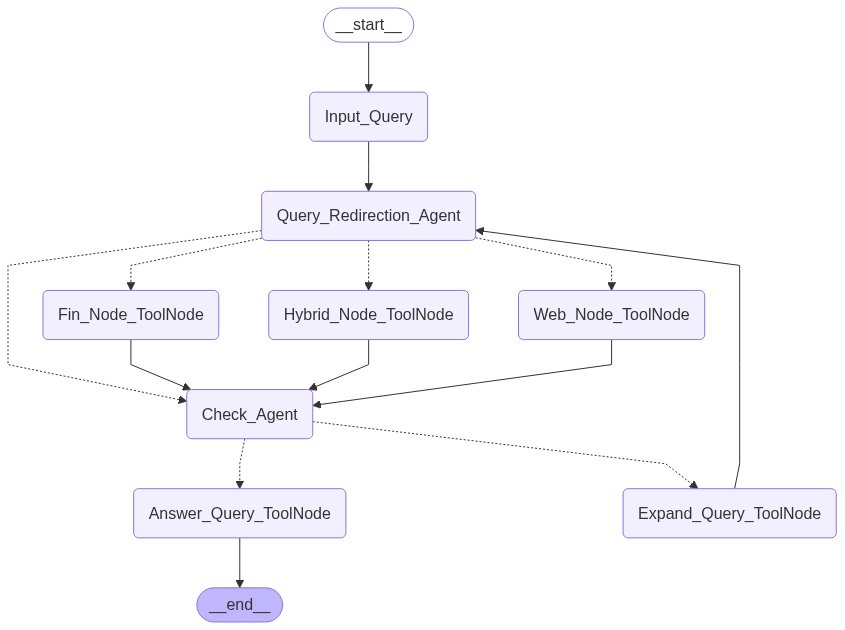

In [5]:

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))